In [ ]:
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 推論程式






路徑與常數

指定 CSV_PATH 只用來推斷訓練波段數（BANDS），MODEL_PATH 指向訓練出的 .keras 模型；定義四類標籤與對應 BGR 顏色（BG=灰、PET=藍、PP=紅、PS=綠）


In [ ]:
# ==== 0) 套件 ====
import os, glob, time
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import load_model

# ==== 1) 路徑與設定（請依實際修改）====
CSV_PATH   = "/content/drive/MyDrive/BL0909/M/ALL.csv"   # 僅用來檢查訓練時的 bands 數
OUT_DIR    = "/content/drive/MyDrive/BL0909/M/MODEL"
IMAGE_DIR  = "/content/drive/MyDrive/BL99"                # 放要推論的灰階線掃 JPG
MODEL_PATH = "/content/drive/MyDrive/BL0909/M/MODEL/0406_MLP_B+3.keras"

os.makedirs(OUT_DIR, exist_ok=True)

# ==== 2) 讀取模型 ====
print("Loading model:", MODEL_PATH)
model = load_model(MODEL_PATH, compile=False)

print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

n_inputs = model.input_shape[-1]
print("Model expects input dim:", int(n_inputs))

Loading model: /content/drive/MyDrive/BL0909/M/MODEL/0406_MLP_B+3.keras
Model input shape: (None, 1235)
Model output shape: (None, 4)
Model expects input dim: 1235


In [ ]:
LABELS = ["BG", "PET", "PP", "PS"]

COLORS = {
    0: (0, 0, 0),       # BG -
    1: (255, 0, 0),     # PET
    2: (0, 0, 255),     # PP
    3: (0, 255, 0)      # PS
}
LABELS = ["BG", "PET", "PP", "PS"]

COLORS = {
     0: (50, 50, 50),       # BG
    1: (255, 0, 0),     # PET
    2: (0, 0, 255),     # PP
    3: (0, 255, 0)      # PS
}

def mixcolor_by_confidence(pred_idx, conf):
    rows = []
    for i, c in enumerate(pred_idx):
        cls_id = int(c)
        if cls_id not in COLORS:
            raise ValueError(f"未知類別索引: {cls_id}, 可用 keys={list(COLORS.keys())}")
        bgr = np.array(COLORS[cls_id], dtype=np.float32)
        rows.append((bgr * float(conf[i])).clip(0, 255))

    row_bgr = np.vstack(rows).astype(np.uint8)   # (W, 3)
    return row_bgr[np.newaxis, :, :]             # (1, W, 3)


載入模型 & 確認輸入維度

load_model 載入後，讀出模型期望輸入維度（應為 1235，用於後續一致性檢查）。


從 CSV 推斷 BANDS

讀 ALL.csv 的前 1 列，數一下最後一欄以外的欄位數 → 得到訓練時的波段數（例如 1232）。

特徵轉換工具：to_features_Bplus3

把一條光譜 (BANDS,) 轉為 (BANDS+3,)：原始光譜 + mean + max + std。
單張影像推論流程：predict_column_spectrum

輸入灰階圖 gray_u8（H×W）。

斷言 H 必須等於 BANDS（高度不符直接報錯）。

將影像轉為 (W, BANDS) 的「逐欄光譜」，可選每欄做 0–1 min-max（預設關閉）。

將每條光譜做 B+3，檢查維度是否等於模型輸入，最後呼叫 model.predict 得到 (W,4) 機率分布。
視覺化工具：mixcolor_by_confidence

將每一欄的預測類別上色（依類別 BGR），亮度乘上該欄最大機率（置信度）→ 產生 (1, W, 3) 彩色條帶。

In [ ]:
# ==== 4) 輔助函式 ====
def to_features_Bplus3(vec_1d: np.ndarray) -> np.ndarray:
    """
    將單一筆光譜（shape=(BANDS,)）轉成 B+3 向量：
    [原始 1232 波段, mean, max, std] → shape=(BANDS+3,)
    """
    mean_v = np.mean(vec_1d, keepdims=True)
    max_v  = np.max(vec_1d,  keepdims=True)
    std_v  = np.std(vec_1d,  keepdims=True)
    return np.concatenate([vec_1d, mean_v, max_v, std_v], axis=0)

def predict_column_spectrum(gray_u8: np.ndarray) -> np.ndarray:
    """
    給一張灰階圖 (H, W)。將每一欄（固定 x）視為一筆光譜（長度=H=BANDS）
    回傳 (W, 4) 的機率分佈。
    """
    H, W = gray_u8.shape
    assert H == BANDS, f"❌ 圖像高度 H={H} 與訓練 bands={BANDS} 不符。請確認資料一致。"

    # 將每欄轉為 (W, BANDS)
    # OpenCV 影像值是 0-255，若你的 CSV 已做過特定歸一化，需一致處理。
    # 這裡提供一個可切換的簡單歸一化範例（預設關閉）：
    DO_MINMAX_PER_COLUMN = False

    X_raw = gray_u8.T.astype(np.float32)  # (W, H) → (W, BANDS)

    if DO_MINMAX_PER_COLUMN:
        # 依每一欄做 min-max 到 0~1（避免亮度差影響）
        min_v = X_raw.min(axis=1, keepdims=True)
        max_v = X_raw.max(axis=1, keepdims=True)
        denom = np.maximum(max_v - min_v, 1e-6)
        X_raw = (X_raw - min_v) / denom

    # 轉 B+3
    X_b3 = np.apply_along_axis(to_features_Bplus3, axis=1, arr=X_raw)  # (W, BANDS+3)

    # 檢查輸入維度
    assert X_b3.shape[1] == n_inputs, f"❌ 模型輸入維度({n_inputs}) 與 X_b3({X_b3.shape[1]}) 不同"

    # 預測
    probs = model.predict(X_b3, verbose=0)  # (W, 4)
    return probs

def mixcolor_by_confidence(pred_idx: np.ndarray, conf: np.ndarray) -> np.ndarray:
    """
    根據類別色 + 置信度 調整亮度。
    pred_idx: (W,)  conf: (W,)
    回傳 (1, W, 3) BGR 圖。
    """
    rows = []
    for i, c in enumerate(pred_idx):
        bgr = np.array(COLORS[int(c)], dtype=np.float32)
        rows.append((bgr * float(conf[i])).clip(0, 255))
    row_bgr = np.vstack(rows).astype(np.uint8)   # (W, 3)
    return row_bgr[np.newaxis, :, :]             # (1, W, 3)


讀取待測影像清單

掃描 IMAGE_DIR 下所有 .jpg，以排序後的名單逐張處理。

In [ ]:
# ==== 5) 讀檔清單 ====
img_paths = sorted(
    [p for p in glob.glob(os.path.join(IMAGE_DIR, "*.jpg"))]
)
print(f"Found {len(img_paths)} JPG in {IMAGE_DIR}")


Found 500 JPG in /content/drive/MyDrive/BL99


逐張推論與統計

讀灰階 → 高度檢查 → predict_column_spectrum 得到機率 → argmax 取類別，max 取置信度。

統計每張圖各類的像素數與平均置信度，存入列表。

每張圖產生一條（1×W×3）彩色條帶，累積到 tiles。

In [ ]:
# ==== 讀 CSV 確認波段數 ====
df = pd.read_csv(CSV_PATH)

# 假設最後一欄是 label
BANDS = df.shape[1] - 1

print("BANDS =", BANDS)
# ==== 6) 逐張處理並拼接 ====
start = time.time()
tiles = []
per_img_stats = []

for p in tqdm(img_paths, desc="Predicting"):
    gray = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"跳過（讀取失敗）：{p}")
        continue

    H, W = gray.shape
    if H != BANDS:
        raise ValueError(f"❌ 高度不符：{os.path.basename(p)} 高度={H}, 需要={BANDS}")

    probs = predict_column_spectrum(gray)     # (W, 4)
    pred  = np.argmax(probs, axis=1)          # (W,)
    conf  = np.max(probs, axis=1)             # (W,)

    # 統計
    uniq, cnt = np.unique(pred, return_counts=True)
    stats = {LABELS[int(k)]: int(v) for k, v in zip(uniq, cnt)}
    stats["file"] = os.path.basename(p)
    stats["mean_conf"] = float(conf.mean())
    per_img_stats.append(stats)

    # 行圖塊（1, W, 3）
    tile = mixcolor_by_confidence(pred, conf)
    tiles.append(tile)

# ==== 7) 整張重建 & 輸出 ====
if tiles:
    recon = np.vstack(tiles)  # (N, W, 3)

    out_img = os.path.join(OUT_DIR, "MLP_Bplus3_Recon_0406.jpg")
    ok = cv2.imwrite(out_img, recon)

    if ok:
        print("✅ Saved:", out_img)
    else:
        print("❌ 圖片存檔失敗:", out_img)

    # 另存統計 CSV
    stats_df = pd.DataFrame(per_img_stats).fillna(0)

    for lab in LABELS:
        if lab not in stats_df.columns:
            stats_df[lab] = 0

    cols = ["file", "mean_conf"] + LABELS
    stats_df = stats_df[cols]

    out_csv = os.path.join(OUT_DIR, "MLP_Bplus3_PerImage_Stats.csv")
    stats_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    print("✅ Saved:", out_csv)

    print(f"⏱️ Time: {time.time() - start:.2f}s")
else:
    print("⚠️ No image processed.")

BANDS = 1232


Predicting: 100%|██████████| 500/500 [06:55<00:00,  1.20it/s]


✅ Saved: /content/drive/MyDrive/BL0909/M/MODEL/MLP_Bplus3_Recon_0406.jpg
✅ Saved: /content/drive/MyDrive/BL0909/M/MODEL/MLP_Bplus3_PerImage_Stats.csv
⏱️ Time: 416.61s


輸出結果

若有處理到影像：

vstack(tiles) 變成整張重建圖（N×W×3），輸出 MLP_Bplus3_Recon_YYYYMMDD.jpg。

建立統計 DataFrame，補齊四類欄，再輸出 MLP_Bplus3_PerImage_Stats.csv（含 file、mean_conf、BG/PET/PP/PS 欄）。

列印總耗時。若沒有影像則提示無處理。

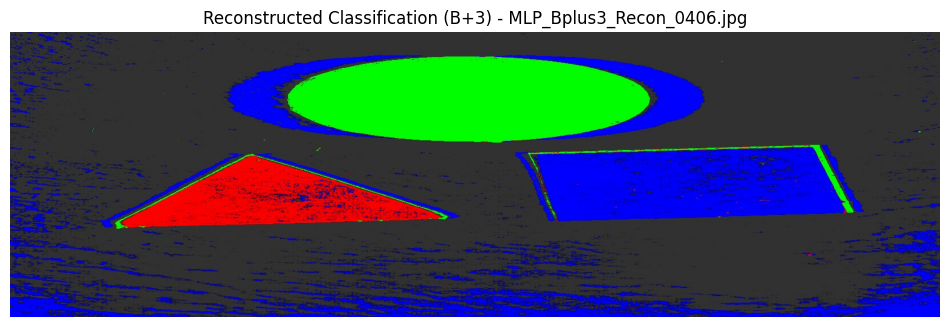

In [ ]:
# ==== 8) 顯示結果圖（Colab 用 matplotlib）====
import matplotlib.pyplot as plt
import glob

# 1) 顯示剛存的重建大圖
latest_imgs = sorted(glob.glob(os.path.join(OUT_DIR, "MLP_Bplus3_Recon_*.jpg")))
if latest_imgs:
    recon_path = latest_imgs[-1]
    recon_bgr  = cv2.imread(recon_path, cv2.IMREAD_COLOR)
    recon_rgb  = cv2.cvtColor(recon_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 12))
    plt.imshow(recon_rgb)
    plt.axis('off')
    plt.title(f"Reconstructed Classification (B+3) - {os.path.basename(recon_path)}")
    plt.show()
else:
    print("找不到重建圖檔（MLP_Bplus3_Recon_*.jpg）。")

